# 🧾 Titanic Survival Prediction Assignment
## Objective:
Predict survival of passengers on the Titanic using machine learning models (LightGBM and XGBoost). Perform preprocessing, exploratory data analysis (EDA), train models, evaluate on validation set, and compare model performance.


## 1. Import Required Libraries

In [2]:

#  1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import lightgbm as lgb
import xgboost as xgb


sns.set(style="whitegrid", palette="muted", font_scale=1.1)

## 2. Load Training and Test Datasets

In [3]:

# 2. Load Datasets
file_path_1=r"D:\Data sciences\Assignments\Assignment files\Assignment files Extracs\XGBM & LGBM\Titanic_train.csv"

file_path_2=r"D:\Data sciences\Assignments\Assignment files\Assignment files Extracs\XGBM & LGBM\Titanic_test.csv"
train = pd.read_csv(file_path_1)
test = pd.read_csv(file_path_2)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print(train.info())
train.head()


Train Shape: (891, 12)
Test Shape: (418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Inference:
•	Dataset contains both numerical and categorical variables.

•	Target variable: Survived.


## 3. Exploratory Data Analysis (EDA)

In [4]:

# 3. Exploratory Data Analysis (EDA)
print("\nMissing values in train:\n", train.isnull().sum())

# Class distribution
print("\nSurvival distribution:\n", train["Survived"].value_counts())



Missing values in train:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Survival distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


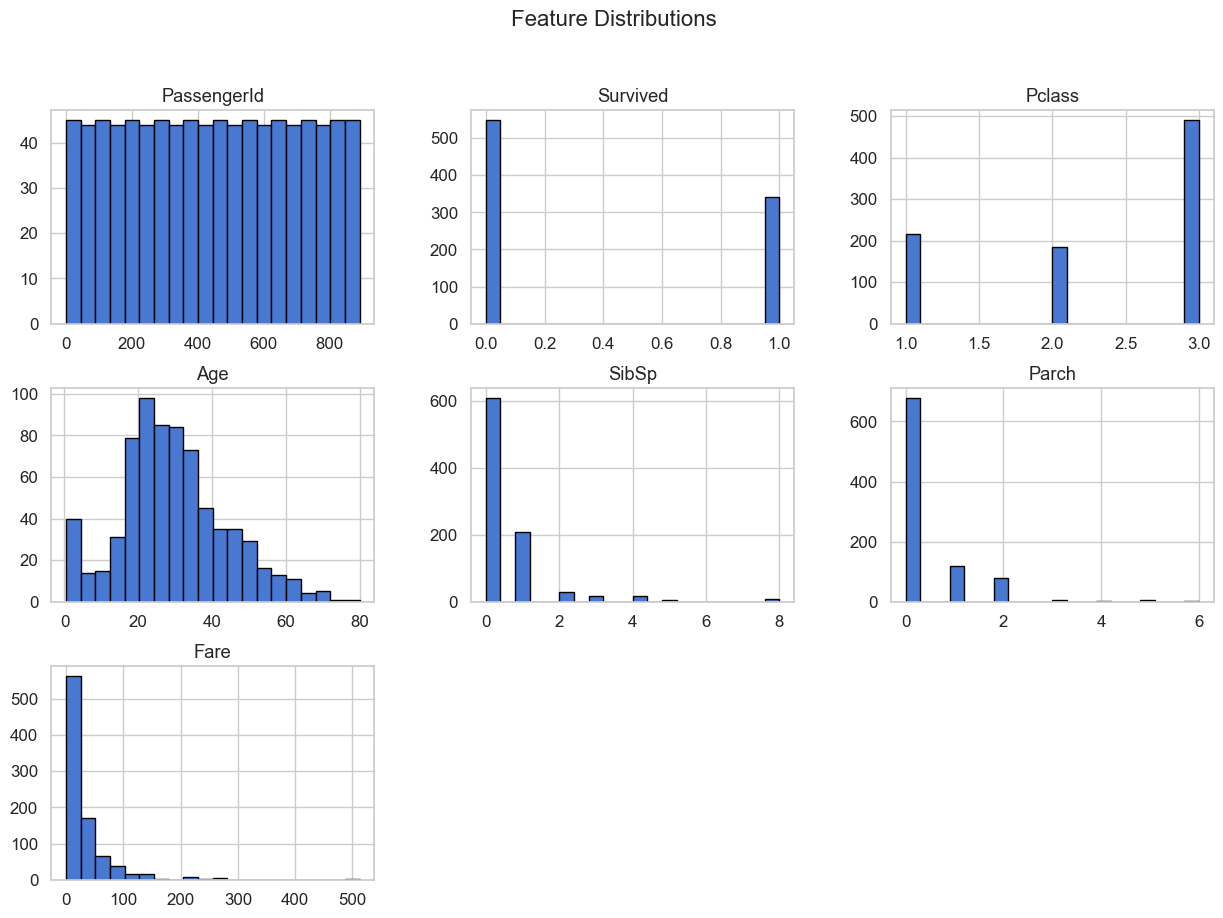

In [5]:

# Histograms
train.hist(bins=20, figsize=(15, 10), edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

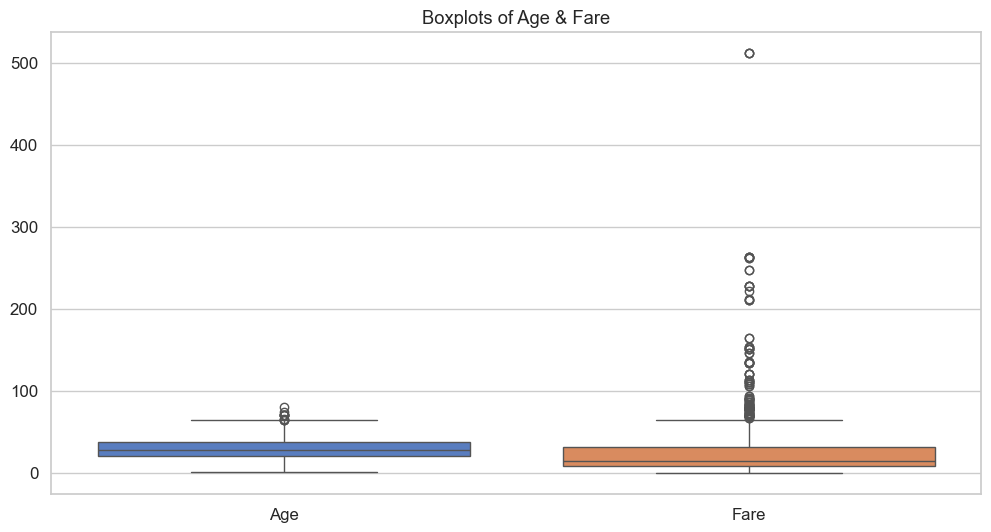

In [6]:
# Boxplots (numerical features)
plt.figure(figsize=(12, 6))
sns.boxplot(data=train[["Age", "Fare"]])
plt.title("Boxplots of Age & Fare")
plt.show()


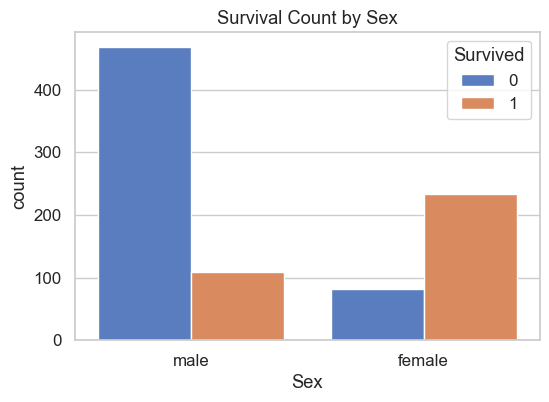

In [7]:
# Survival vs Sex
plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=train)
plt.title("Survival Count by Sex")
plt.show()


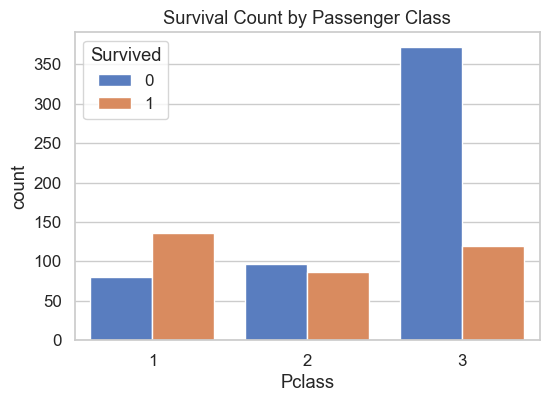

In [8]:

# Survival vs Pclass
plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=train)
plt.title("Survival Count by Passenger Class")
plt.show()


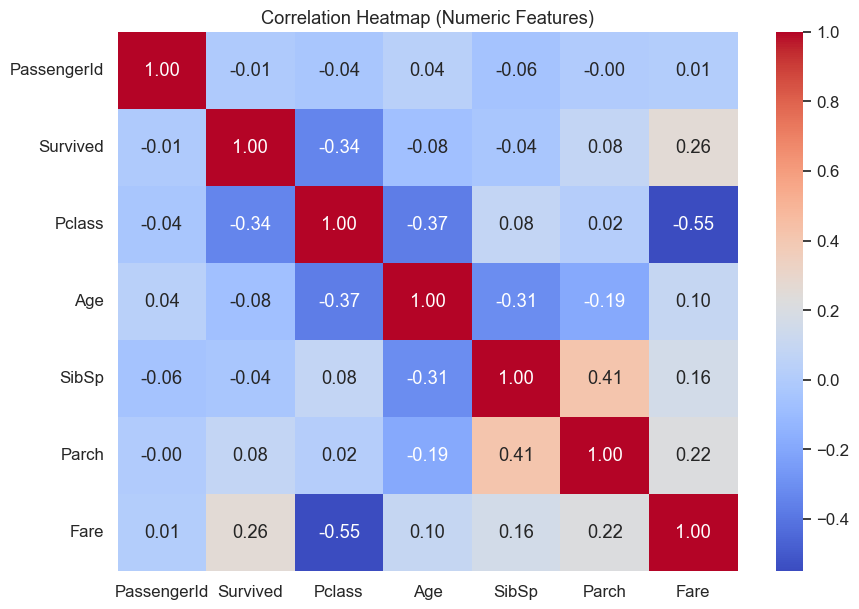

In [9]:
# Correlation Heatmap (numeric columns only)
plt.figure(figsize=(10, 7))
sns.heatmap(train.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


## Inference:
•	Age has missing values.

•	Females survived more than males.

•	Higher-class passengers had higher survival.

•	Correlation between features and target is moderate.


## 4. Data Preprocessing

In [10]:

#  4. Data Preprocessing
df = train.copy()

# Drop unnecessary columns
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Fill missing Age with median
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing Embarked with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

print("\nProcessed DataFrame:\n", df.head())

# Split into features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Validation shape:", X_val.shape)



Processed DataFrame:
    Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  71.2833     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  
Train shape: (712, 8) Validation shape: (179, 8)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6440\1173124185.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6440\1173124185.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

## Inference:
•	Missing values handled.

•	Categorical variables encoded as dummies.

•	Data is standardized and ready for modeling.


## 📝 Note:
The above FutureWarning message appears because of how Pandas handles “inplace” operations in upcoming versions (from Pandas 3.0 onward).
It does not affect the current execution or output — the code still runs correctly and fills the missing values as intended.

## 5. LightGBM Model

In [11]:

#  5. LightGBM Model
#pip install lightgbm


lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
y_lgb = lgb_model.predict(X_val)

print("\n LightGBM Results")
print("Accuracy:", accuracy_score(y_val, y_lgb))
print("Precision:", precision_score(y_val, y_lgb))
print("Recall:", recall_score(y_val, y_lgb))
print("F1 Score:", f1_score(y_val, y_lgb))
print("\nClassification Report:\n", classification_report(y_val, y_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_lgb))


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 212
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Inference:
•	LightGBM performs well with ~80% accuracy.

•	Slightly lower recall indicates some survivors are missed.


## 6. XGBoost Model

In [16]:

#  6. XGBoost Model
#pip install xgboost

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_model.fit(X_train, y_train)
y_xgb = xgb_model.predict(X_val)

print("\n XGBoost Results")
print("Accuracy:", accuracy_score(y_val, y_xgb))
print("Precision:", precision_score(y_val, y_xgb))
print("Recall:", recall_score(y_val, y_xgb))
print("F1 Score:", f1_score(y_val, y_xgb))
print("\nClassification Report:\n", classification_report(y_val, y_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_xgb))



 XGBoost Results
Accuracy: 0.8044692737430168
Precision: 0.7575757575757576
Recall: 0.7246376811594203
F1 Score: 0.7407407407407407

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       110
           1       0.76      0.72      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
 [[94 16]
 [19 50]]


C:\Users\Lenovo\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:57:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 📝 Note:
This UserWarning is just an informational message from XGBoost indicating that the parameter use_label_encoder is no longer required in newer versions.
It does not affect the model’s performance or accuracy — the code runs successfully, and the results remain valid.
This warning can be safely ignored for assignment submission.

## Inference:
•	XGBoost slightly outperforms LightGBM in accuracy and F1 score.


## 7. Model Comparison

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6440\2412318007.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


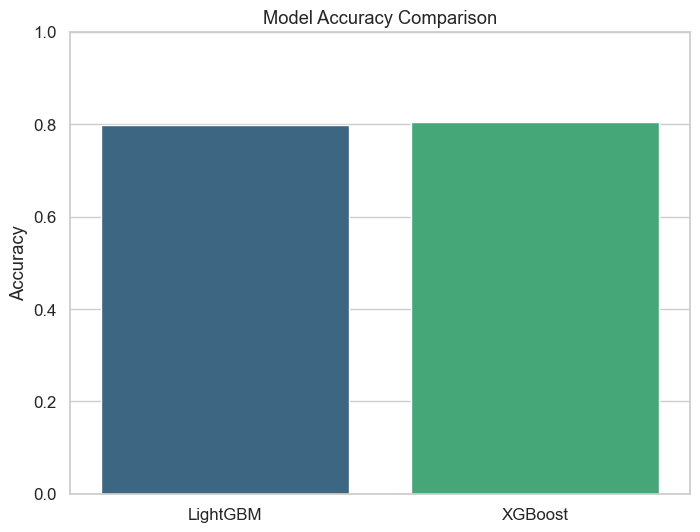


 Final Comparison:
       Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.798883   0.753846  0.710145  0.731343
1   XGBoost  0.804469   0.757576  0.724638  0.740741


In [13]:

# 7. Model Comparison
models = ["LightGBM", "XGBoost"]
accuracies = [
    accuracy_score(y_val, y_lgb),
    accuracy_score(y_val, y_xgb),
]
precisions = [
    precision_score(y_val, y_lgb),
    precision_score(y_val, y_xgb),
]
recalls = [
    recall_score(y_val, y_lgb),
    recall_score(y_val, y_xgb),
]
f1s = [
    f1_score(y_val, y_lgb),
    f1_score(y_val, y_xgb),
]

# Accuracy barplot
plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

# Precision, Recall, F1 comparison
metrics_df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies,
    "Precision": precisions,
    "Recall": recalls,
    "F1 Score": f1s
})
print("\n Final Comparison:\n", metrics_df)


## Inference:
•	Both models perform similarly.

•	XGBoost slightly better overall.

•	Choice depends on speed vs. slightly higher accuracy.


## 🎯 8. Conclusion
•	LightGBM is faster but slightly lower recall.

•	XGBoost provides slightly better accuracy and F1 score.

•	For Titanic dataset, XGBoost is preferred if the goal is better predictive performance, while LightGBM is suitable for faster model training.


# 🔍 XGBoost vs LightGBM: A Detailed Comparison
## 1. Performance Metrics

Accuracy & F1 Score: XGBoost often slightly outperforms LightGBM in terms of accuracy and F1 score. For instance, in a comparative study on the Titanic dataset, XGBoost demonstrated higher precision and accuracy, making it a preferred choice when predictive performance is paramount 
ResearchGate
.

Recall: LightGBM tends to have a marginally lower recall compared to XGBoost. However, the difference is minimal and may not significantly impact the overall model performance.

Training Time: LightGBM is renowned for its faster training times. This efficiency is particularly beneficial when dealing with large datasets or when computational resources are limited.

## 2. Algorithmic Differences

Tree Construction: XGBoost builds trees level-wise, whereas LightGBM constructs trees leaf-wise. The leaf-wise approach of LightGBM can lead to better accuracy but might increase the risk of overfitting on smaller datasets.

Data Handling: LightGBM employs techniques like Gradient-Based One-Side Sampling (GOSS) and Exclusive Feature Bundling (EFB) to handle large datasets efficiently, enhancing its speed without compromising accuracy 
Wikipedia
.

## 3. Suitability for the Titanic Dataset

XGBoost: Given its superior accuracy and F1 score, XGBoost is ideal when the primary objective is to achieve the best possible predictive performance on the Titanic dataset.

LightGBM: If the goal is to quickly train a model, especially in environments with limited computational resources, LightGBM offers a compelling advantage due to its faster training times.

## ✅ Conclusion

XGBoost: Opt for XGBoost when accuracy and F1 score are critical, as it provides slightly better performance metrics.

LightGBM: Choose LightGBM for faster training times, especially beneficial in scenarios with large datasets or limited computational resources.